# Semantic Features: comparison demo

This notebook demonstrates incorporating `semantic_analysis.analyze_curve` features into a simple classifier and compares performance with a baseline feature set (no semantic features).

In [6]:
# Standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pathlib, sys
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
np.random.seed(0)
# Ensure repo dir is importable and import semantic_analysis
p = pathlib.Path.cwd()
if str(p) not in sys.path:
    sys.path.insert(0, str(p))
from semantic_analysis import analyze_curve

In [7]:
# Helpers: synthetic curve generators and dataset builder
def gen_linear(x, slope=1.0, intercept=0.0, noise=0.1):
    return intercept + slope * x + np.random.normal(scale=noise, size=x.shape)

def gen_sine(x, amp=1.0, freq=1.0, phase=0.0, noise=0.1):
    return amp * np.sin(2 * np.pi * freq * x + phase) + np.random.normal(scale=noise, size=x.shape)

def gen_flat(x, level=0.0, noise=0.2):
    return level + np.random.normal(scale=noise, size=x.shape)

def make_curve_pair(x, y):
    return np.vstack([x, y]).T

def build_dataset(n_per_class=200, n_points=100):
    X_raw = []
    labels = []
    xs = np.linspace(0, 1, n_points)
    for _ in range(n_per_class):
        y = gen_linear(xs, slope=2.0 * np.random.rand() + 0.3, intercept=np.random.randn()*0.2, noise=0.15)
        X_raw.append(make_curve_pair(xs, y)); labels.append('increasing')
        y = gen_linear(xs, slope=-(2.0 * np.random.rand() + 0.3), intercept=np.random.randn()*0.2, noise=0.15)
        X_raw.append(make_curve_pair(xs, y)); labels.append('decreasing')
        y = gen_sine(xs, amp=0.8 + 0.6*np.random.rand(), freq=3.0*(0.8+0.4*np.random.rand()), phase=np.random.rand()*2*np.pi, noise=0.15)
        X_raw.append(make_curve_pair(xs, y)); labels.append('sine')
        y = gen_flat(xs, level=np.random.randn()*0.1, noise=0.3)
        X_raw.append(make_curve_pair(xs, y)); labels.append('flat')
    return X_raw, labels

In [8]:
# Baseline feature extractor (no semantic features)
def baseline_features(curve):
    x = curve[:,0]
    y = curve[:,1]
    mean = float(np.mean(y))
    std = float(np.std(y))
    ptp = float(np.ptp(y))
    # simple slope estimate via linear fit
    if len(x) >= 2:
        slope = float(np.polyfit(x, y, 1)[0])
    else:
        slope = 0.0
    mn = float(np.min(y)); mx = float(np.max(y))
    return {'mean': mean, 'std': std, 'ptp': ptp, 'slope': slope, 'min': mn, 'max': mx}

In [9]:
# Semantic feature wrapper: uses analyze_curve output and maps to numeric features
def semantic_features(curve):
    res = analyze_curve(curve)
    # map trend categories to numeric
    trend_map = {'increasing': 1, 'decreasing': -1, 'flat': 0}
    trend_num = trend_map.get(res.get('trend','flat'), 0)
    slope = float(res.get('slope', 0.0))
    slope_thresh = float(res.get('slope_threshold', 0.0))
    is_sine = 1 if res.get('is_sine_like', False) else 0
    period = float(res.get('period') or 0.0)
    freq = float(res.get('frequency') or 0.0)
    curvature = float(res.get('curvature') or 0.0)
    convexity = int(res.get('convexity') or 0)
    return {'trend_num': trend_num, 'slope_sem': slope, 'slope_thresh': slope_thresh, 'is_sine': is_sine, 'period': period, 'freq': freq, 'curvature': curvature, 'convexity': convexity}

In [10]:
# Build dataset and compare models
X_raw, labels = build_dataset(n_per_class=120, n_points=120)
# extract features
rows_base = []
rows_sem = []
for curve, lab in zip(X_raw, labels):
    b = baseline_features(curve)
    s = semantic_features(curve)
    merged = {**b, **s}
    rows_base.append({**b, 'label': lab})
    rows_sem.append({**merged, 'label': lab})
df_base = pd.DataFrame(rows_base)
df_sem = pd.DataFrame(rows_sem)
# Prepare X/y
le = LabelEncoder(); y = le.fit_transform(df_base['label'])
Xb = df_base.drop(columns=['label']).values
Xs = df_sem.drop(columns=['label']).values
# train/test split
Xb_tr, Xb_te, y_tr, y_te = train_test_split(Xb, y, test_size=0.3, random_state=1, stratify=y)
Xs_tr, Xs_te, _, _ = train_test_split(Xs, y, test_size=0.3, random_state=1, stratify=y)
# Fit simple logistic regression classifiers
clf_b = LogisticRegression(max_iter=200).fit(Xb_tr, y_tr)
clf_s = LogisticRegression(max_iter=200).fit(Xs_tr, y_tr)
pred_b = clf_b.predict(Xb_te)
pred_s = clf_s.predict(Xs_te)
acc_b = accuracy_score(y_te, pred_b)
acc_s = accuracy_score(y_te, pred_s)
acc_b, acc_s

(0.9791666666666666, 1.0)

Baseline accuracy: 0.9792
With semantic features: 1.0000


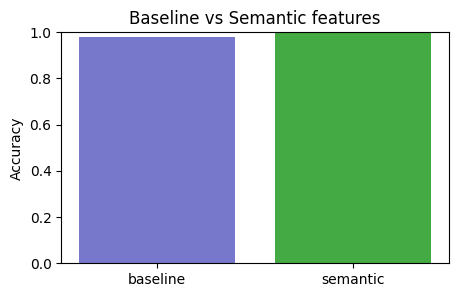

In [11]:
# Display comparison and a simple bar plot
print(f'Baseline accuracy: {acc_b:.4f}')
print(f'With semantic features: {acc_s:.4f}')
plt.figure(figsize=(5,3))
plt.bar(['baseline','semantic'], [acc_b, acc_s], color=['#7777cc','#44aa44'])
plt.ylim(0,1); plt.ylabel('Accuracy'); plt.title('Baseline vs Semantic features')
plt.show()

**Summary**:
- This notebook builds a small synthetic benchmark and trains a lightweight classifier using either baseline statistical features or the baseline plus semantic features produced by `analyze_curve()`.
- The printed accuracies and bar chart compare performance with and without semantic features; you can adapt dataset size, noise, and the final model to test real data or the project's final model pipeline.